Author: Malachy McCaffrey
Date: 07/08/2026

Pre- STC Diagnostics Workflow

Diagnostics:
1) Temporal Completeness (observed months / total study months per grid ID)
    * Decision Threshold: Mean Completeness
        i) Strong: > 0.50
        ii) Moderate: 0.20 - 0.50
        iii) Weak: < 0.20
2) Monthly Occupancy (active cells / total cells per month)
    * Decision Threshold: Average Occupancy
        i) Strong: > 0.20
        ii) Moderate: > 0.10 - 0.20
        iii) Weak: < 0.10
3) Persistent Activity (no. of active months per grid ID)
    * Decision Threshold: No. Active Months
        i) Very Strong: >= 24 months
        ii) Strong: >= 12 months

### Pre Step: Define working environment

In [11]:
import arcpy
from arcpy import env
import pandas as pd
import os
import csv

env.workspace = r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\VesselResponses_SNE.gdb"
env.overwriteOutput = True

workspace = r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\VesselResponses_SNE.gdb"

### Step 1: Load point feature class into pandas

In [2]:
# input fc

fc = r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\VesselResponses_SNE.gdb\\gfw_vp_fv_stc_utm19n"

fields = [
    "Grid_ID",
    "Year_Month",
    "Vessel_Presence_Hours",
    "Vessel_Count"
]

rows = []

with arcpy.da.SearchCursor(
    fc,
    fields
) as cursor:
    for row in cursor:
        rows.append(row)

df = pd.DataFrame(
    rows, 
    columns = fields
)

df["Year_Month"] = pd.to_datetime(
    df["Year_Month"]
)

print(df.head())

   Grid_ID Year_Month  Vessel_Presence_Hours  Vessel_Count
0        1 2016-08-01                      1             1
1        1 2016-09-01                      4             3
2        1 2018-08-01                      1             1
3        1 2018-11-01                      1             1
4        1 2019-09-01                      1             1


### Step 2: Calculate Study Duration

In [3]:
start_date = df["Year_Month"].min()

end_date = df["Year_Month"].max()

total_months = (
    (end_date.year - start_date.year) * 12 
    + end_date.month
    - start_date.month
    + 1
)

print("Start Date:", start_date)
print("End Date:", end_date)
print("Total Months:", total_months)

Start Date: 2016-01-01 00:00:00
End Date: 2026-05-01 00:00:00
Total Months: 125


### Step 3: Temporal Completeness

A location with only 2 observed months is unlikely to support robust trend detection.

A location with 36 observed months is much more informative.

In [4]:
# calculate temporal completeness for each grid cell

temporal_completeness = (
    df.groupby("Grid_ID")
    ["Year_Month"]
    .nunique()
    .reset_index()
)

temporal_completeness.rename(
    columns = {
        "Year_Month": "ObservedMonths"
    },
    inplace = True
)

temporal_completeness["Completeness"] = (
    temporal_completeness["ObservedMonths"] / total_months
)

In [6]:
# view summary

print(
    temporal_completeness[
        "Completeness"
    ].describe()
)
# mean completeness = 0.16... not good. on avg only 16% of the months were observed in any given grid cell. This is a problem for the analysis since we are trying to assess temporal patterns in vessel activity across the study area.

# count 3359 corresponds to unique no. of unique lat/lon pts in the study area... also no. of unique grid cells in the study area.

median_completeness = temporal_completeness["Completeness"].median()
print(median_completeness)

# median completeness = 0.13...

count    3359.000000
mean        0.157066
std         0.114898
min         0.008000
25%         0.080000
50%         0.128000
75%         0.200000
max         0.688000
Name: Completeness, dtype: float64
0.128


In [42]:
# export csv

temporal_completeness.to_csv(
    r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\diagnostics\\gfw_vp_fv_temporal_completeness.csv",
    index = False
)

In [57]:
## create mappable completeness layer

completeness_lookup = dict(
    zip(
        temporal_completeness["Grid_ID"],
        temporal_completeness["Completeness"]
    )
)

# create copy

completeness_fc = (
    r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\VesselResponses_SNE.gdb\\TemporalCompleteness"
)

arcpy.management.CopyFeatures(
    fc,
    completeness_fc
)

# add field

arcpy.management.AddField(
    completeness_fc,
    "Completeness",
    "DOUBLE"
)

# populate completeness field

with arcpy.da.UpdateCursor(
    completeness_fc,
    ["Grid_ID", "Completeness"]
) as cursor:
    for row in cursor:
        row[1] = completeness_lookup.get(row[0])
        cursor.updateRow(row)

# graduated symbology in ArcGIS Pro project

### Step 4: Monthly Occupancy

How much of the study area was active during each month?

This reveals:
* seasonal changes
* sparse periods
* unusual gaps

In [14]:
# determine total unique cells

total_cells = (
    df["Grid_ID"]
    .nunique()
)

print("Total Unique Cells:", total_cells) # knew this from prev step

Total Unique Cells: 3359


In [15]:
# calculate monthly active cells

monthly_occupancy = (
    df.groupby("Year_Month")
    ["Grid_ID"]
    .nunique()
    .reset_index()  
)

monthly_occupancy.rename(
    columns = {
        "Grid_ID": "ActiveCells"
    },
    inplace = True
)

monthly_occupancy["Occupancy"] = (
    monthly_occupancy["ActiveCells"] / total_cells
)

In [16]:
# view summary

print(
    monthly_occupancy[
        "Occupancy"
    ].describe()
)

# mean occupancy = 0.16 is okay... on avg 16% of cells were active in any given month...
# same value as mean temporal completeness... makes sense since the same data is being used to calculate both metrics

count    125.000000
mean       0.157066
std        0.081388
min        0.006550
25%        0.100625
50%        0.142007
75%        0.211075
max        0.368860
Name: Occupancy, dtype: float64


In [43]:
# export csv

monthly_occupancy.to_csv(
    r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\diagnostics\\gfw_vp_fv_monthly_occupancy.csv",
    index = False
)

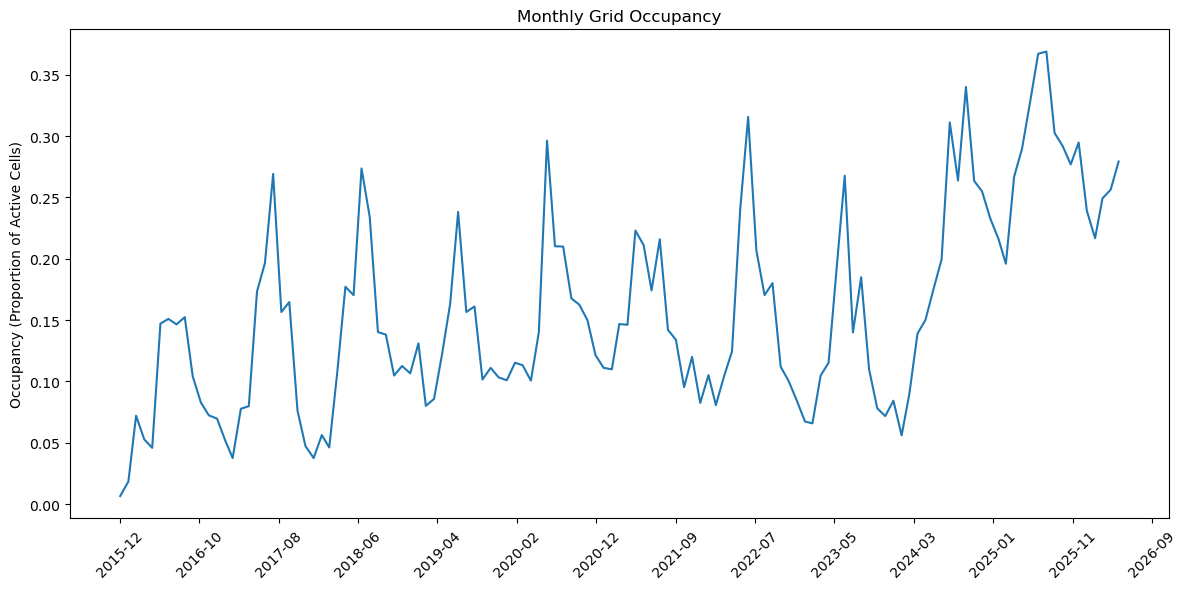

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot monthly occupancy
# A time series chart quickly reveals:
    # seasonal peaks
    # long-term expansion/contraction
    # anomalous months

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

plt.figure(
    figsize = (12,6)
)

ax = plt.gca()
ax.plot(monthly_occupancy["Year_Month"], monthly_occupancy["Occupancy"])

# limit to 15 x-axis ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=15))

# format dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation = 45)

plt.ylabel("Occupancy (Proportion of Active Cells)")

plt.title("Monthly Grid Occupancy")

plt.tight_layout()

plt.show()

# save plot as png file using button at top right of plot window

### Step 5: Persistent Activity

This metric identifies locations that repeatedly support vessel activity.

In [40]:
# calculate no. of active months per grid cell

persistent_activity = (
    df.groupby("Grid_ID")
    ["Year_Month"]
    .nunique()
    .reset_index()
)

persistent_activity.rename(
    columns = {
        "Year_Month": "Active_Months"
    },
    inplace = True
)

In [45]:
# export csv

persistent_activity.to_csv(
    r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\diagnostics\\gfw_vp_fv_persistent_activity.csv",
    index = False
)

In [50]:
# group cells into persistence categories for easier interpretation

def classify_persistence(x):
    if x <= 3:
        return "1-3 Months"
    elif x <= 12:
        return "4-12 Months"
    elif x <= 24:
        return "13-24 Months"
    else:
        return "25+ Months"
    
persistent_activity[
        "PersistenceClass"
        ] = (
            persistent_activity[
                "Active_Months"
                ].apply(
                    classify_persistence
                )
)

In [ ]:
# frequency table

print(
    persistent_activity[
        "PersistenceClass"
    ].value_counts()
)

print(
    "Cells Active ≥ 12 Months:",
    (
        persistent_activity[
            "Active_Months"
        ] >= 12
    ).sum()
)

print(
    "Cells Active ≥ 24 Months:",
    (
        persistent_activity[
            "Active_Months"
        ] >= 24
    ).sum()
)

# these number look good so we can move forward with STC analysis

PersistenceClass
13-24 Months    1248
4-12 Months     1094
25+ Months       876
1-3 Months       141
Name: count, dtype: int64
Cells Active ≥ 12 Months: 2266
Cells Active ≥ 24 Months: 928


In [58]:
## create mappable persistence layer

persistence_lookup = dict(
    zip(
        persistent_activity["Grid_ID"],
        persistent_activity["Active_Months"]
    )
)

# create copy

persistence_fc = (
    r"C:\\Users\\mmccaffrey17\\ArcGIS\\Projects\\VesselResponses_SNE\\VesselResponses_SNE.gdb\\PersistentActivity"
)

arcpy.management.CopyFeatures(
    fc,
    persistence_fc
)

# add field

arcpy.management.AddField(
    persistence_fc,
    "Active_Months",
    "LONG"
)

# populate persistence field

with arcpy.da.UpdateCursor(
    persistence_fc,
    ["Grid_ID", "Active_Months"]
) as cursor:
    for row in cursor:
        row[1] = persistence_lookup.get(row[0])
        cursor.updateRow(row)

# graduated symbology in ArcGIS Pro project